# Dementia: complexity measures at fixed history length

Compare CN vs. AD (same subjects as `03_dementia_higher_order_syntax.ipynb`) using
**entropy rate (ER)** and **excess entropy (EE)** -- the slope and intercept of
`mstsa.entropy_rate`'s linear fit -- at a single fixed history length `kmax=5`, for
both the continuous microstate sequence and its jump (embedded) sequence.

In [4]:
import os

data_path = "/home/frederic/data/eeg/ds004504/derivatives/pycrostates/ms"
f_participants = "/home/frederic/data/eeg/ds004504/participants.tsv"

subjects = [f.split('_')[0] for f in os.listdir(data_path) if f.endswith('.npy')]
with open(f_participants, 'r') as fp:
    lines = fp.readlines()
lines = [l.strip().split('\t') for l in lines[1:]]
subjects_CN = [l[0] for l in lines if l[3] == 'C']
subjects_AD = [l[0] for l in lines if l[3] == 'A']

ms_files = {
    'CN': sorted([f"{data_path}/{subj}_EC_ms_K4.npy"
                  for subj in subjects if subj in subjects_CN]),
    'AD': sorted([f"{data_path}/{subj}_EC_ms_K4.npy"
                  for subj in subjects if subj in subjects_AD]),
}
print(f"CN: {len(ms_files['CN'])}")
print(f"AD: {len(ms_files['AD'])}")

CN: 24
AD: 25


## Entropy rate and excess entropy, kmax=5

For each subject's continuous microstate sequence (truncated to `n_max=100000`
samples) and its jump (embedded) sequence, `mstsa.entropy_rate(x, K, kmax=5)` fits
joint entropy vs. block length over blocks `1..kmax+1` and returns:
- `er` -- entropy rate (slope): the asymptotic bits/sample needed to describe a new
  symbol given its history,
- `ee` -- excess entropy (intercept): the amount of predictable structure/memory in
  the sequence beyond what the entropy rate alone accounts for.

Per-subject results are cached to disk (`data/cache/complexity_kmax5/*.npz`), so
re-running only computes subjects that aren't cached yet.

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import mstsa

K = 4
n_max = int(1e5)
kmax = 5

cache_dir = "../data/cache/complexity_kmax5"
os.makedirs(cache_dir, exist_ok=True)

_KEYS = ['er_full', 'ee_full', 'er_jump', 'ee_jump']


def _compute_subject(f, K, n_max, kmax):
    x = np.load(f).astype(np.int32)
    x = x[:n_max]

    er_full, ee_full = mstsa.entropy_rate(x, K, kmax=kmax)

    jump, _ = mstsa.embedded_process(x)
    er_jump, ee_jump = mstsa.entropy_rate(jump, K, kmax=kmax)

    return dict(er_full=er_full, ee_full=ee_full, er_jump=er_jump, ee_jump=ee_jump)


def analyze_subject(f, K=K, n_max=n_max, kmax=kmax, cache_dir=cache_dir, force=False):
    cache_file = os.path.join(cache_dir, os.path.basename(f).replace('.npy', '_complexity.npz'))
    if os.path.exists(cache_file) and not force:
        d = np.load(cache_file)
        if all(k in d.files for k in _KEYS):
            return {k: float(d[k]) for k in _KEYS}
    res = _compute_subject(f, K, n_max, kmax)
    np.savez(cache_file, **res)
    return res


def analyze_group(files, max_subjects=None, **kwargs):
    files = files[:max_subjects] if max_subjects else files
    results = []
    for i, f in enumerate(files):
        cache_file = os.path.join(cache_dir, os.path.basename(f).replace('.npy', '_complexity.npz'))
        cached = os.path.exists(cache_file)
        t0 = time.time()
        res = analyze_subject(f, **kwargs)
        tag = "cached" if cached else f"{time.time() - t0:.1f}s"
        print(f"  [{i + 1}/{len(files)}] {os.path.basename(f)} ({tag})")
        results.append(res)
    return results

In [5]:
max_subjects = None  # full population

group_results = {}
for group in ['CN', 'AD']:
    print(f"=== {group} ===")
    group_results[group] = analyze_group(ms_files[group], max_subjects=max_subjects)

=== CN ===
  [1/24] sub-037_EC_ms_K4.npy (cached)
  [2/24] sub-038_EC_ms_K4.npy (cached)
  [3/24] sub-040_EC_ms_K4.npy (cached)
  [4/24] sub-041_EC_ms_K4.npy (cached)
  [5/24] sub-042_EC_ms_K4.npy (cached)
  [6/24] sub-043_EC_ms_K4.npy (cached)
  [7/24] sub-044_EC_ms_K4.npy (cached)
  [8/24] sub-045_EC_ms_K4.npy (cached)
  [9/24] sub-046_EC_ms_K4.npy (cached)
  [10/24] sub-047_EC_ms_K4.npy (cached)
  [11/24] sub-048_EC_ms_K4.npy (cached)
  [12/24] sub-049_EC_ms_K4.npy (cached)
  [13/24] sub-050_EC_ms_K4.npy (cached)
  [14/24] sub-052_EC_ms_K4.npy (cached)
  [15/24] sub-053_EC_ms_K4.npy (cached)
  [16/24] sub-054_EC_ms_K4.npy (cached)
  [17/24] sub-055_EC_ms_K4.npy (cached)
  [18/24] sub-057_EC_ms_K4.npy (cached)
  [19/24] sub-059_EC_ms_K4.npy (cached)
  [20/24] sub-060_EC_ms_K4.npy (cached)
  [21/24] sub-061_EC_ms_K4.npy (cached)
  [22/24] sub-063_EC_ms_K4.npy (cached)
  [23/24] sub-064_EC_ms_K4.npy (cached)
  [24/24] sub-065_EC_ms_K4.npy (cached)
=== AD ===
  [1/25] sub-001_EC_ms_K4.n

In [6]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu


def _values(results, key):
    return np.array([r[key] for r in results])


_PANELS = [
    ('er_full', 'continuous sequences: entropy rate', 'ER (bits/sample)'),
    ('ee_full', 'continuous sequences: excess entropy', 'EE (bits)'),
    ('er_jump', 'jump sequences: entropy rate', 'ER (bits/sample)'),
    ('ee_jump', 'jump sequences: excess entropy', 'EE (bits)'),
]


def compare_groups(cn, ad, alpha=0.05):
    """Pick t-test vs. Mann-Whitney U from a Shapiro-Wilk normality check on each
    group (both must pass to use a t-test); if normal, a Levene test on variance
    homogeneity picks Welch's vs. Student's t-test."""
    p_norm_cn = shapiro(cn).pvalue
    p_norm_ad = shapiro(ad).pvalue
    normal = (p_norm_cn > alpha) and (p_norm_ad > alpha)
    if normal:
        equal_var = levene(cn, ad).pvalue > alpha
        stat, p = ttest_ind(cn, ad, equal_var=equal_var)
        test = "Welch's t" if not equal_var else "Student's t"
    else:
        stat, p = mannwhitneyu(cn, ad)
        test = 'Mann-Whitney U'
    return dict(test=test, statistic=stat, pvalue=p,
                normal_cn=p_norm_cn, normal_ad=p_norm_ad, normal=normal)


def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


stats_results = {}
print(f"{'metric':10s} {'CN mean':>9s} {'AD mean':>9s}  {'Shapiro CN':>11s} {'Shapiro AD':>11s} "
      f"{'test':>14s} {'p-value':>10s}  sig")
for key, title, _ in _PANELS:
    cn = _values(group_results['CN'], key)
    ad = _values(group_results['AD'], key)
    res = compare_groups(cn, ad)
    stats_results[key] = res
    print(f"{key:10s} {cn.mean():9.4f} {ad.mean():9.4f}  {res['normal_cn']:11.4g} {res['normal_ad']:11.4g} "
          f"{res['test']:>14s} {res['pvalue']:10.4g}  {sig_stars(res['pvalue'])}")

metric       CN mean   AD mean   Shapiro CN  Shapiro AD           test    p-value  sig
er_full       0.5250    0.4875       0.2293      0.8011      Welch's t   0.003206  **
ee_full       1.3951    1.4742       0.0281      0.1411 Mann-Whitney U  0.0001506  ***
er_jump       1.4928    1.5257      0.02044    0.003104 Mann-Whitney U    0.01207  *
ee_jump       0.5040    0.4819      0.00626     0.02947 Mann-Whitney U    0.04036  *


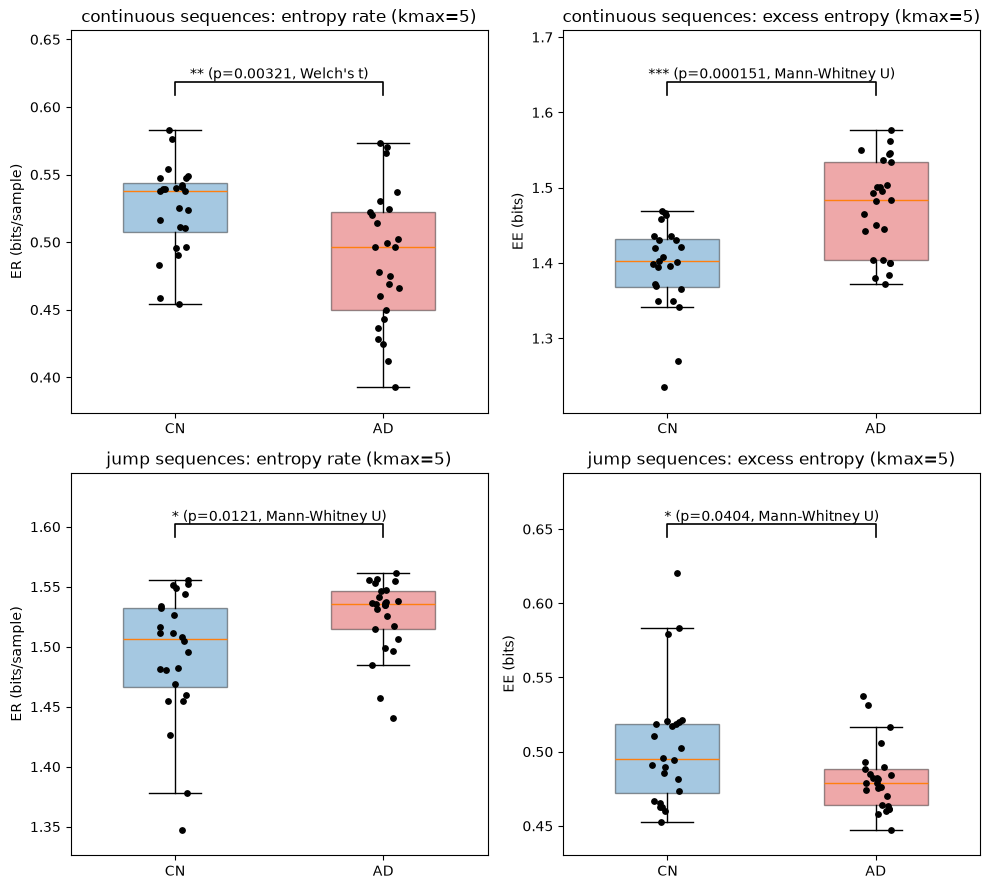

In [7]:
def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='k')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom')


def plot_complexity(group_results, stats_results, kmax=kmax):
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    rng = np.random.default_rng(0)
    for ax, (key, title, ylabel) in zip(axes.flat, _PANELS):
        data = [_values(group_results[g], key) for g in ['CN', 'AD']]
        bp = ax.boxplot(data, tick_labels=['CN', 'AD'], patch_artist=True, widths=0.5,
                         showfliers=False)
        for patch, color in zip(bp['boxes'], ['tab:blue', 'tab:red']):
            patch.set_facecolor(color)
            patch.set_alpha(0.4)
        for i, d in enumerate(data, start=1):
            jitter = (rng.random(len(d)) - 0.5) * 0.15
            ax.scatter(np.full(len(d), i) + jitter, d, color='k', s=15, zorder=3)

        ymax = max(d.max() for d in data)
        ymin = min(d.min() for d in data)
        span = ymax - ymin
        bracket_y = ymax + 0.14 * span
        bracket_h = 0.05 * span
        ax.set_ylim(ymin - 0.10 * span, bracket_y + 5 * bracket_h)
        p = stats_results[key]['pvalue']
        label = f"{sig_stars(p)} (p={p:.3g}, {stats_results[key]['test']})"
        add_sig_bracket(ax, 1, 2, bracket_y, bracket_h, label)

        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} (kmax={kmax})')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/02_complexity_kmax5.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_complexity(group_results, stats_results)

## Entropy rate vs. excess entropy: complexity-plane scatter

`entropy_rate` (ER, the slope of `mstsa.entropy_rate`'s fit) is a **type I**
complexity measure -- the asymptotic unpredictability of the next symbol -- while
`excess_entropy` (EE, the intercept) is a **type II** measure -- the amount of
structure/memory the sequence carries beyond that asymptotic rate. Plotting every
subject as one point in the `(ER, EE)` plane, rather than comparing the two measures
separately per group (as in the boxplots above), shows whether CN and AD subjects
separate jointly on both axes at once, and whether that separation looks different
for the continuous microstate sequence vs. its jump (embedded) counterpart.

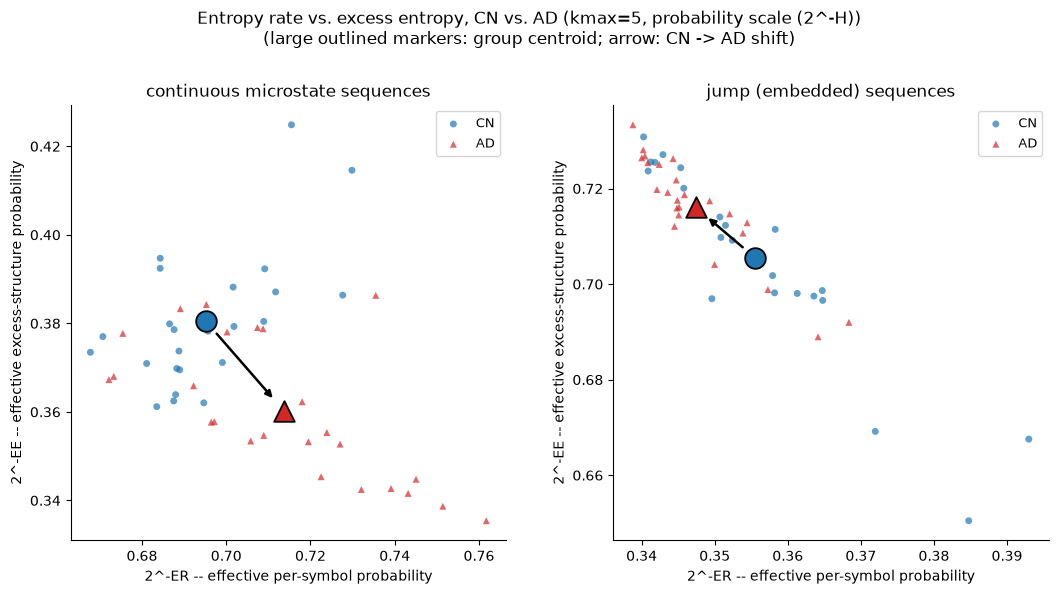

In [ ]:
def plot_er_ee_scatter(group_results, kmax=kmax, use_probability_scale=False):
    """use_probability_scale=True undoes the log2 in ER/EE (both are log2 of an
    underlying probability: ER ~ -log2(p) per symbol, EE ~ -log2(p) of the excess
    predictable structure), plotting 2**-ER and 2**-EE instead -- i.e. the
    probabilities themselves rather than their log2. Note EE is a total (bits),
    not a per-sample rate like ER, so 2**-EE is not itself a per-symbol
    probability, but the same inverse-log2 transform undoes its log compression."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    panels = [
        (axes[0], 'er_full', 'ee_full', 'continuous microstate sequences'),
        (axes[1], 'er_jump', 'ee_jump', 'jump (embedded) sequences'),
    ]
    colors = {'CN': 'tab:blue', 'AD': 'tab:red'}
    markers = {'CN': 'o', 'AD': '^'}

    def transform(x):
        return 2.0 ** (-x) if use_probability_scale else x

    for ax, er_key, ee_key, title in panels:
        centroids = {}
        for group in ['CN', 'AD']:
            er = transform(_values(group_results[group], er_key))
            ee = transform(_values(group_results[group], ee_key))
            ax.scatter(er, ee, color=colors[group], marker=markers[group],
                       s=25, alpha=0.7, edgecolors='none', label=group)
            centroids[group] = (er.mean(), ee.mean())
            # center of gravity: group mean (ER, EE), drawn larger with a black
            # outline so it stands out against the individual-subject points
            ax.scatter(*centroids[group], color=colors[group], marker=markers[group],
                       s=220, edgecolors='k', linewidths=1.3, zorder=5)

        # arrow from the CN centroid to the AD centroid, showing the direction of
        # the group shift in the (ER, EE) plane
        ax.annotate('', xy=centroids['AD'], xytext=centroids['CN'],
                    arrowprops=dict(arrowstyle='-|>', color='k', lw=1.8,
                                     shrinkA=12, shrinkB=12), zorder=4)

        if use_probability_scale:
            ax.set_xlabel('2^-ER -- effective per-symbol probability')
            ax.set_ylabel('2^-EE -- effective excess-structure probability')
        else:
            ax.set_xlabel('entropy rate ER (bits/sample) -- type I complexity')
            ax.set_ylabel('excess entropy EE (bits) -- type II complexity')
        ax.set_title(title)
        ax.set_box_aspect(1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=9)

    scale_note = 'probability scale (2^-H)' if use_probability_scale else 'log2 (bits) scale'
    fig.suptitle(f'Entropy rate vs. excess entropy, CN vs. AD (kmax={kmax}, {scale_note})\n'
                 '(large outlined markers: group centroid; arrow: CN -> AD shift)', y=1.04)
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    fname = 'figures/02_er_ee_scatter_prob.png' if use_probability_scale else 'figures/02_er_ee_scatter.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_er_ee_scatter(group_results, use_probability_scale=False)